In [1]:
!pip install torch pydantic matplotlib numpy

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from traffic_env import TrafficSignalEnv
from agent import MultiAgentDQN, obs_to_tensor

🚀 Starting 4-Agent Cooperative Training...
Episode 50 | Avg Reward: 0.6666 | Avg Network Queue: 24.9
Episode 100 | Avg Reward: 0.6728 | Avg Network Queue: 22.0
Episode 150 | Avg Reward: 0.6809 | Avg Network Queue: 19.6
Episode 200 | Avg Reward: 0.6825 | Avg Network Queue: 19.3
Episode 250 | Avg Reward: 0.6838 | Avg Network Queue: 18.0
Episode 300 | Avg Reward: 0.6913 | Avg Network Queue: 15.9
Episode 350 | Avg Reward: 0.6904 | Avg Network Queue: 16.6
Episode 400 | Avg Reward: 0.6931 | Avg Network Queue: 15.4
Episode 450 | Avg Reward: 0.6914 | Avg Network Queue: 16.1
Episode 500 | Avg Reward: 0.6907 | Avg Network Queue: 15.7
Episode 550 | Avg Reward: 0.6941 | Avg Network Queue: 15.0
Episode 600 | Avg Reward: 0.6969 | Avg Network Queue: 14.1


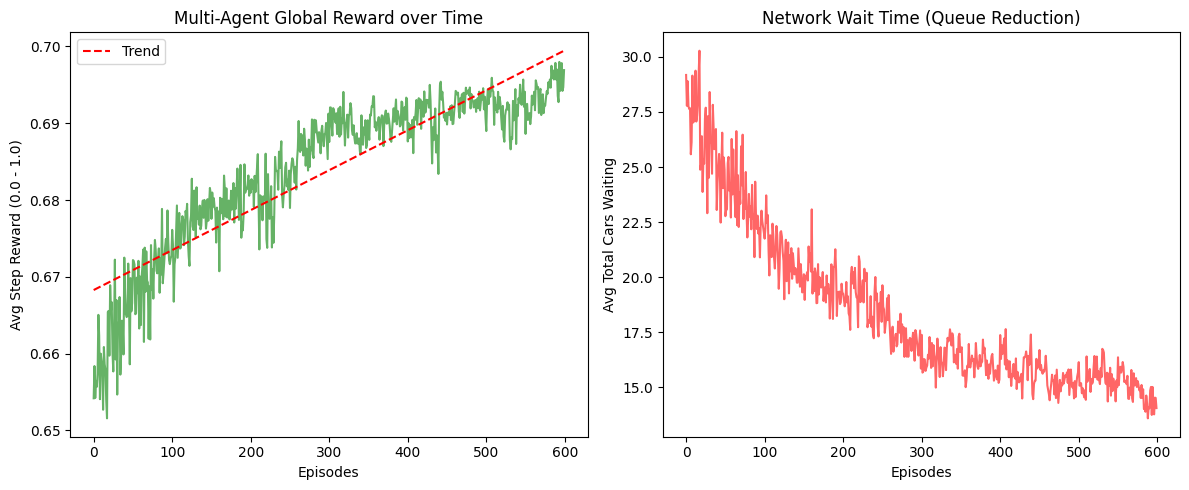

✅ Training complete. 'training_results.png' saved.


In [6]:
def train_and_plot(episodes=600):
    env = TrafficSignalEnv(seed=42, mode="medium")
    agent = MultiAgentDQN()
    agent.eps_decay = int(episodes * 0.6 * 200)

    global_rewards = []
    avg_queues = []

    print("🚀 Starting 4-Agent Cooperative Training...")
    for ep in range(1, episodes + 1):
        obs_dict, done = env.reset(), False
        ep_reward = 0
        queue_history = []

        while not done:
            action = agent.select_action(obs_dict)
            next_obs_dict, reward, done, info = env.step(action)

            # Parameter sharing: train on all 4 agents
            for i in range(4):
                aid = f"agent_{i}"
                score = info['agent_scores'][i]
                agent.buffer.push(obs_to_tensor(obs_dict[aid]), getattr(action, aid), score, obs_to_tensor(next_obs_dict[aid]), float(done))
            agent.update()

            # Tracking metrics
            ep_reward += reward
            queue_history.append(sum(o.north_queue + o.south_queue + o.east_queue + o.west_queue for o in next_obs_dict.values()))
            obs_dict = next_obs_dict

        if ep % 10 == 0: agent.update_target()

        global_rewards.append(ep_reward / 200) # Avg step reward
        avg_queues.append(np.mean(queue_history))

        if ep % 50 == 0:
            print(f"Episode {ep} | Avg Reward: {global_rewards[-1]:.4f} | Avg Network Queue: {avg_queues[-1]:.1f}")

    agent.save("dqn_traffic_4x4_baseline.pth")

    # --- GENERATE JUDGE-COMPLIANT PLOTS ---
    plt.figure(figsize=(12, 5))

    # Plot 1: Global Reward
    plt.subplot(1, 2, 1)
    plt.plot(global_rewards, color='green', alpha=0.6)
    # Trendline
    z = np.polyfit(range(len(global_rewards)), global_rewards, 1)
    p = np.poly1d(z)
    plt.plot(range(len(global_rewards)), p(range(len(global_rewards))), "r--", label="Trend")
    plt.title("Multi-Agent Global Reward over Time")
    plt.xlabel("Episodes")
    plt.ylabel("Avg Step Reward (0.0 - 1.0)")
    plt.legend()

    # Plot 2: Queue Reduction
    plt.subplot(1, 2, 2)
    plt.plot(avg_queues, color='red', alpha=0.6)
    plt.title("Network Wait Time (Queue Reduction)")
    plt.xlabel("Episodes")
    plt.ylabel("Avg Total Cars Waiting")

    plt.tight_layout()
    plt.savefig("training_results.png")
    plt.show()
    print("✅ Training complete. 'training_results.png' saved.")

train_and_plot(600)